In [1]:
# Step 0: imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Optional display improvements for notebooks
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

# Step 1: load
df = pd.read_csv('final_dataset.csv')  # replace filename as needed

# Quick view
print(df.shape)
df.head()


(1050, 15)


,TransactionID,Date,Time,Company,LocationID,City,FuelType,Quantity_Liters,Price_per_Litre,Total_Amount,PaymentMethod,VehicleType,LoyaltyCardUsed,PumpNumber,EmployeeID
0,TXN001,2024-01-03,05:44:00,HP,delhi-pump-04,delhi,petrol,26.30,94.46,2484.30,UPI,car,No,3,E-DEL-4
1,TXN002,2025-02-04,21:08:00,IOCL,pune-pump-01,pune,diesel,42.89,87.57,3755.88,Card,car,Yes,5,E-PUN-3
2,TXN003,2024-08-25,06:39:00,BPCL,mumbai-pump-02,mumbai,diesel,10.42,88.11,918.11,Card,bike,Yes,1,E-MUM-2
3,TXN004,2025-01-05,15:20:00,IOCL,bangalore-pump-07,bangalore,petrol,14.49,95.10,1378.00,Cash,bike,No,2,E-BAN-1
4,TXN005,2025-04-09,19:52:00,HP,mumbai-pump-02,mumbai,diesel,39.37,87.21,3433.46,Cash,car,No,5,E-MUM-5


In [2]:
# Overall totals
tot_transactions = len(df)
tot_volume = df['Quantity_Liters'].sum()
tot_revenue = df['Total_Amount'].sum()
avg_price_per_litre = df['Price_per_Litre'].mean()
avg_volume_per_txn = df['Quantity_Liters'].mean()

summary = {
    'total_transactions': tot_transactions,
    'total_volume_liters': tot_volume,
    'total_revenue': tot_revenue,
    'avg_price_per_litre': avg_price_per_litre,
    'avg_volume_per_transaction': avg_volume_per_txn
}
print(summary)

# Distribution/description
df[['Quantity_Liters', 'Price_per_Litre', 'Total_Amount']].describe()


{'total_transactions': 1050, 'total_volume_liters': np.float64(23154.590000000004), 'total_revenue': np.float64(2173729.8600000003), 'avg_price_per_litre': np.float64(93.80059047619048), 'avg_volume_per_transaction': np.float64(22.05199047619048)}


,Quantity_Liters,Price_per_Litre,Total_Amount
count,1050.000000,1050.000000,1050.000000
mean,22.051990,93.800590,2070.218914
std,13.664761,4.808417,1291.521560
min,5.000000,87.120000,446.190000
25%,10.192500,87.842500,947.542500
50%,17.170000,94.670000,1605.475000
75%,34.265000,99.150000,3175.350000
max,49.870000,99.950000,4944.650000


In [ ]:
# Fuel preference (which fuel sells most by volume and revenue)

By volume:
 FuelType
petrol          8327.30
diesel          7570.45
power petrol    7256.84
Name: Quantity_Liters, dtype: float64
By revenue:
 FuelType
petrol          788709.27
power petrol    721708.81
diesel          663311.78
Name: Total_Amount, dtype: float64


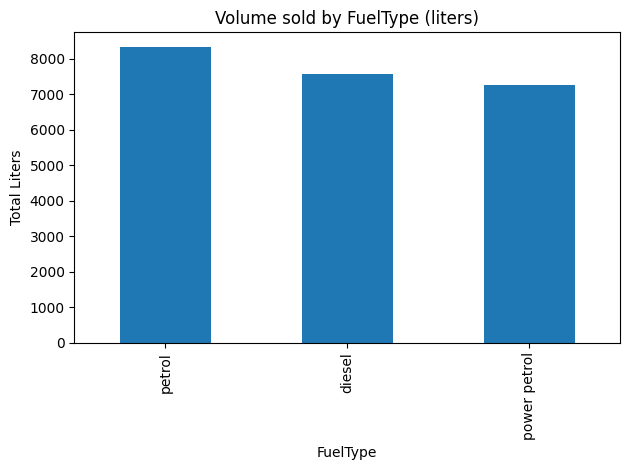

In [3]:
fuel_volume = df.groupby('FuelType')['Quantity_Liters'].sum().sort_values(ascending=False)
fuel_revenue = df.groupby('FuelType')['Total_Amount'].sum().sort_values(ascending=False)

print("By volume:\n", fuel_volume)
print("By revenue:\n", fuel_revenue)

# Plot
ax = fuel_volume.plot(kind='bar', title='Volume sold by FuelType (liters)')
ax.set_ylabel('Total Liters')
plt.tight_layout()
plt.show()


PaymentMethod
UPI     388
Card    347
Cash    315
Name: count, dtype: int64
PaymentMethod
UPI     0.369524
Card    0.330476
Cash    0.300000
Name: count, dtype: float64
PaymentMethod
Card    2133.556542
Cash    2085.381841
UPI     2001.264072
Name: Total_Amount, dtype: float64


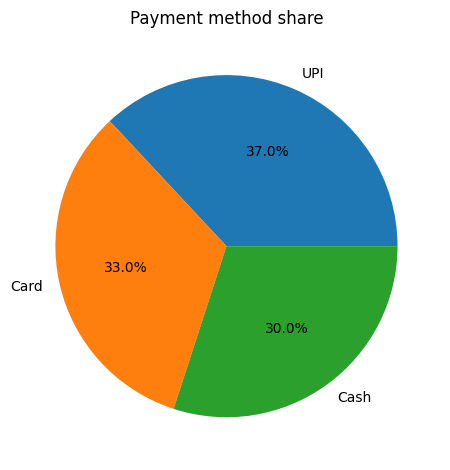

In [4]:
# Payment methods (counts, share, average spend)


pm_counts = df['PaymentMethod'].value_counts(dropna=False)
pm_share = pm_counts / pm_counts.sum()
pm_avg_spend = df.groupby('PaymentMethod')['Total_Amount'].mean().sort_values(ascending=False)

print(pm_counts)
print(pm_share)
print(pm_avg_spend)

# Pie chart for share
pm_share.plot(kind='pie', autopct='%1.1f%%', ylabel='', title='Payment method share')
plt.tight_layout()
plt.show()


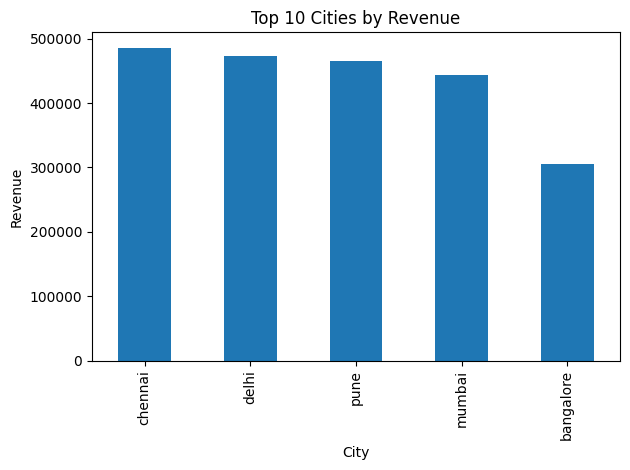

In [5]:
# City / Location analysis

city_totals = df.groupby('City').agg(
    transactions=('TransactionID', 'count'),
    volume_liters=('Quantity_Liters', 'sum'),
    revenue=('Total_Amount', 'sum')
).sort_values('revenue', ascending=False)

city_totals.head(20)

# Visual: top 10 cities by revenue
city_totals['revenue'].head(10).plot(kind='bar', title='Top 10 Cities by Revenue')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()


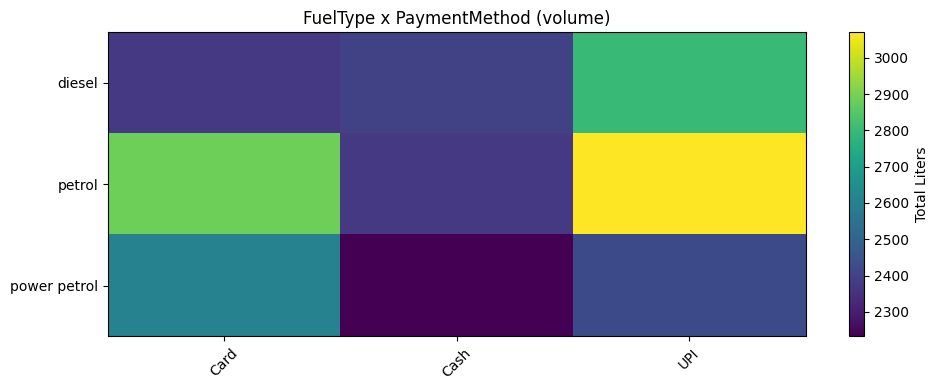

In [7]:
# Pivot: fuel type vs payment method (volume)
pivot_fp = pd.pivot_table(df, index='FuelType', columns='PaymentMethod', values='Quantity_Liters', aggfunc='sum', fill_value=0)
pivot_fp

# Heatmap-style view using values (if you want to visualize, you can use imshow or seaborn)
plt.figure(figsize=(10,4))
plt.title('FuelType x PaymentMethod (volume)')
plt.imshow(pivot_fp, aspect='auto')
plt.xticks(range(len(pivot_fp.columns)), pivot_fp.columns, rotation=45)
plt.yticks(range(len(pivot_fp.index)), pivot_fp.index)
plt.colorbar(label='Total Liters')
plt.tight_layout()
plt.show()


In [8]:
# Pump & Employee insights (performance)


# Top pumps by volume and revenue
pump_stats = df.groupby('PumpNumber').agg(volume=('Quantity_Liters','sum'), revenue=('Total_Amount','sum')).sort_values('volume', ascending=False)
pump_stats.head(10)

# Employee sales — top performers
emp_stats = df.groupby('EmployeeID').agg(transactions=('TransactionID','count'), revenue=('Total_Amount','sum')).sort_values('revenue', ascending=False)
emp_stats.head(10)


,transactions,revenue
EmployeeID,,
E-CHE-5,53,116813.77
E-PUN-5,55,110150.99
E-MUM-4,51,107491.06
E-PUN-2,48,106470.87
E-MUM-1,46,105170.17
E-DEL-1,50,103065.56
E-CHE-2,43,99763.08
E-CHE-1,49,98658.73
E-DEL-3,49,97019.10


In [10]:
def quick_report(df):
    print("Shape:", df.shape)
    print("\n--- Head ---")
    display(df.head())
    print("\n--- Dtypes ---")
    print(df.dtypes)
    print("\n--- Missing % ---")
    print((df.isna().sum()/len(df)*100).sort_values(ascending=False).head(10))
    print("\n--- Basic stats ---")
    display(df[['Quantity_Liters','Price_per_Litre','Total_Amount']].describe())

# usage
quick_report(df)


Shape: (1050, 15)

--- Head ---


,TransactionID,Date,Time,Company,LocationID,City,FuelType,Quantity_Liters,Price_per_Litre,Total_Amount,PaymentMethod,VehicleType,LoyaltyCardUsed,PumpNumber,EmployeeID
0,TXN001,2024-01-03,05:44:00,HP,delhi-pump-04,delhi,petrol,26.30,94.46,2484.30,UPI,car,No,3,E-DEL-4
1,TXN002,2025-02-04,21:08:00,IOCL,pune-pump-01,pune,diesel,42.89,87.57,3755.88,Card,car,Yes,5,E-PUN-3
2,TXN003,2024-08-25,06:39:00,BPCL,mumbai-pump-02,mumbai,diesel,10.42,88.11,918.11,Card,bike,Yes,1,E-MUM-2
3,TXN004,2025-01-05,15:20:00,IOCL,bangalore-pump-07,bangalore,petrol,14.49,95.10,1378.00,Cash,bike,No,2,E-BAN-1
4,TXN005,2025-04-09,19:52:00,HP,mumbai-pump-02,mumbai,diesel,39.37,87.21,3433.46,Cash,car,No,5,E-MUM-5



--- Dtypes ---
TransactionID       object
Date                object
Time                object
Company             object
LocationID          object
City                object
FuelType            object
Quantity_Liters    float64
Price_per_Litre    float64
Total_Amount       float64
PaymentMethod       object
VehicleType         object
LoyaltyCardUsed     object
PumpNumber           int64
EmployeeID          object
dtype: object

--- Missing % ---
TransactionID      0.0
Date               0.0
Time               0.0
Company            0.0
LocationID         0.0
City               0.0
FuelType           0.0
Quantity_Liters    0.0
Price_per_Litre    0.0
Total_Amount       0.0
dtype: float64

--- Basic stats ---


,Quantity_Liters,Price_per_Litre,Total_Amount
count,1050.000000,1050.000000,1050.000000
mean,22.051990,93.800590,2070.218914
std,13.664761,4.808417,1291.521560
min,5.000000,87.120000,446.190000
25%,10.192500,87.842500,947.542500
50%,17.170000,94.670000,1605.475000
75%,34.265000,99.150000,3175.350000
max,49.870000,99.950000,4944.650000
